In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/aaqibqadeer/Hotel-booking-demand/master/hotel_bookings.csv"
df = pd.read_csv(url)

In [2]:
# Load dataset (Step 1)
url = "https://raw.githubusercontent.com/aaqibqadeer/Hotel-booking-demand/master/hotel_bookings.csv"
df = pd.read_csv(url)

# Calculate missing value counts and percentages
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100

# Create a summary dataframe and filter for columns with missing values
missing_data = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage (%)': missing_percentage
})

# Filter out complete columns and sort
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(missing_data)

          Missing_Count  Percentage (%)
company          112593       94.306893
agent             16340       13.686238
country             488        0.408744
children              4        0.003350


In [3]:
# 1. Drop the 'company' column due to extreme sparsity
df = df.drop(columns=['company'])

# 2. Fill 'agent' with 0 to indicate a direct booking
df['agent'] = df['agent'].fillna(0)

# 3. Fill missing 'country' with 'Unknown' to avoid data leakage from mode imputation
df['country'] = df['country'].fillna('Unknown')

# 4. Fill missing 'children' with 0
df['children'] = df['children'].fillna(0)

# Verification
print(df.isnull().sum().max()) # Should output 0, confirming no missing values remain

0


In [4]:
# 1. Eliminate Data Leakage
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

# 2. Remove Structural Anomalies
# Keep only valid bookings with at least 1 guest and 1 night
valid_guests_mask = (df['adults'] + df['children'] + df['babies']) > 0
valid_nights_mask = (df['stays_in_weekend_nights'] + df['stays_in_week_nights']) > 0
df = df[valid_guests_mask & valid_nights_mask].copy()

# 3. Generate Derived Features
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['room_assignment_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# 4. Temporal Engineering (Numerical Mapping)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month_num'] = df['arrival_date_month'].map(month_map)

# We can now safely drop the original string month column
df = df.drop(columns=['arrival_date_month'])

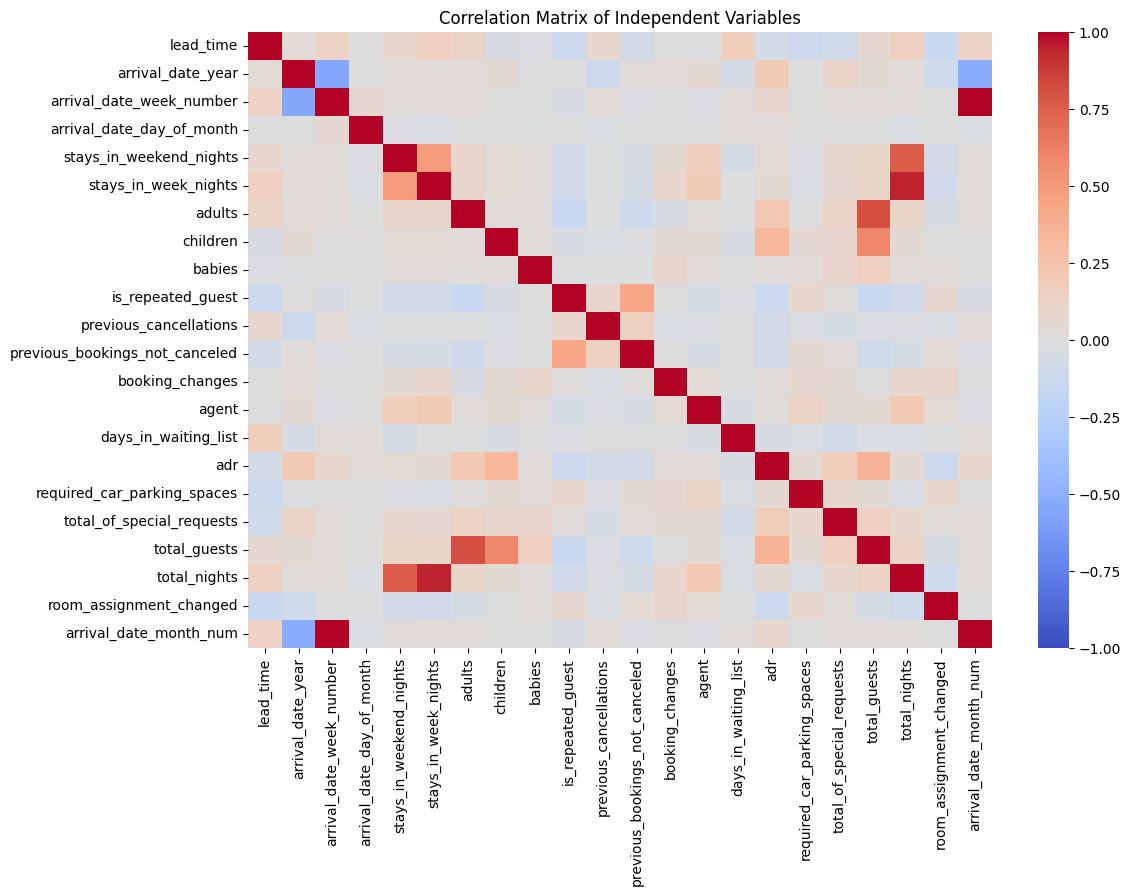

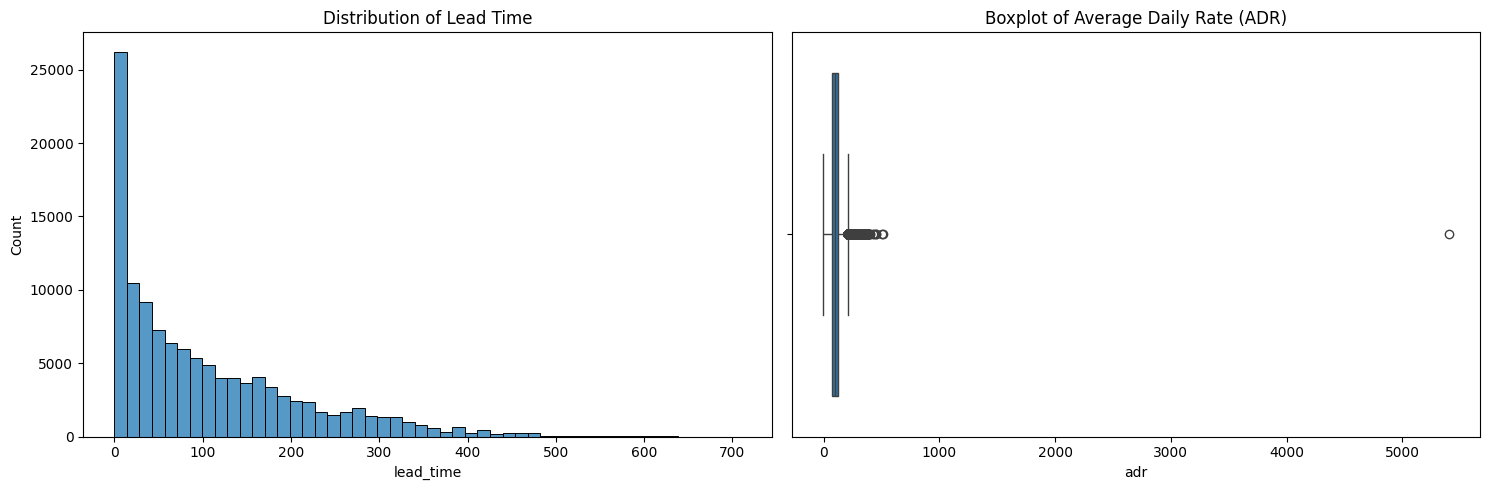

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check for Multicollinearity (Independent Variables Only)
# Drop the target variable before calculating the correlation matrix
numeric_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['is_canceled'])
corr_matrix = numeric_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Independent Variables")
plt.show()

# 2. Visualize Feature Distributions (Outlier Detection)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Example: Distribution of Lead Time
sns.histplot(df['lead_time'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Lead Time')

# Example: Average Daily Rate (ADR) Boxplot to spot extreme values
sns.boxplot(x=df['adr'], ax=axes[1])
axes[1].set_title('Boxplot of Average Daily Rate (ADR)')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# 1. Separate the independent variables (X) from the target variable (y)
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# 2. Execute the Stratified Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # This forces proportional representation
)

# 3. Verify the Stratification
print("Original Dataset Cancellation Rate: {:.2f}%".format(y.mean() * 100))
print("Training Set Cancellation Rate:     {:.2f}%".format(y_train.mean() * 100))
print("Testing Set Cancellation Rate:      {:.2f}%".format(y_test.mean() * 100))

Original Dataset Cancellation Rate: 37.26%
Training Set Cancellation Rate:     37.26%
Testing Set Cancellation Rate:      37.26%


In [7]:
# High-cardinality categorical feature
high_card_cat_features = ['country']

# Low-cardinality categorical features
low_card_cat_features = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type'
]

# Numeric features (everything else in X_train)
numeric_features = [col for col in X_train.columns
                    if col not in high_card_cat_features + low_card_cat_features]

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

# Pipeline for numeric features: Impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for low-cardinality categoricals: Impute with mode, then One-Hot Encode
low_card_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline for high-cardinality categoricals: Target Encoding
# Note: TargetEncoder is available natively in scikit-learn >= 1.3
high_card_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(target_type='binary'))
])

In [9]:
# Combine all transformers into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_low', low_card_cat_transformer, low_card_cat_features),
        ('cat_high', high_card_cat_transformer, high_card_cat_features)
    ],
    remainder='drop' # Drops any columns not explicitly specified above
)

In [10]:
# Fit the pipeline on the training data ONLY, and transform X_train
X_train_processed = preprocessor.fit_transform(X_train, y_train)

# Transform the testing data using the learned parameters (NO fitting)
X_test_processed = preprocessor.transform(X_test)

# Verify the transformation shape
print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (94852, 31)
Processed X_train shape: (94852, 70)
